# Perturb-seq preprocessing: ABE dataset

Prepares the ABE Perturb-seq log-count matrix for downstream analysis.

**Getting the data**

Download `logcounts_ABE.csv` and `meta_ABE.csv` from Zenodo
([doi:10.5281/zenodo.16951444](https://doi.org/10.5281/zenodo.16951444)), which holds the processed single-cell
base-editing data accompanying Fig.7 of:

> Coelho, M. A. *et al.* Base editing screens define the genetic landscape of cancer drug resistance mechanisms.
> *Nat Genet* **56**, 2479–2492 (2024).

The two HGNC files are included in this repository's `data/` folder.

**Folder layout**

Place the input files in a `data/` folder next to this notebook. The `output/` folder is created automatically.

```
├── Perturb-seq_processing.ipynb
├── data/
│   ├── logcounts_ABE.csv               genes × cells log-normalised counts
│   ├── meta_ABE.csv                    per-cell metadata (gRNA, variant_class_highest_impact)
│   ├── protein-coding_genes_HGNC.txt   HGNC protein-coding gene set (from genenames.org)
│   └── hgnc-symbol-check.csv           HGNC Multi-Symbol Checker results (see step 5a)
└── output/
    ├── symbols_for_hgnc_check.txt
    └── data_checkpoint.csv
```

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

data_dir = Path("data")
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

random_state = 42
np.random.seed(random_state)

## Load data

In [3]:
logcounts = pd.read_csv(data_dir / "logcounts_ABE.csv")
meta = pd.read_csv(data_dir / "meta_ABE.csv")

# Transpose to cells x genes and attach metadata (aligned on cell ID)
expr = logcounts.T
expr["variant_class_highest_impact"] = meta["variant_class_highest_impact"]
expr["gRNA"] = meta["gRNA"]

# Fail if metadata does not line up with the expression matrix
assert expr["variant_class_highest_impact"].notna().all(), \
    "Metadata did not align with expression matrix"
expr.shape

(9505, 36603)

## Select single- and double-guide cells

Cell IDs contain one `iBAR` tag per guide. For double-guide cells, each guide's variant class
is looked up from the single-guide cells. A double-guide cell is kept only if its two guides
have different classes, so the phenotype can be attributed to one of them.

In [5]:
n_ibar = expr.index.str.count("iBAR")
single = expr[n_ibar == 1]
double = expr[n_ibar == 2]

# Map each guide to its variant class using single-guide cells
grna_to_class = single.set_index("gRNA")["variant_class_highest_impact"].to_dict()

double_guides = double[["variant_class_highest_impact", "gRNA"]].copy()
double_guides[["grna1", "grna2"]] = double_guides["gRNA"].str.split("-", n=1, expand=True)
double_guides["class1"] = double_guides["grna1"].map(grna_to_class)
double_guides["class2"] = double_guides["grna2"].map(grna_to_class)

# Note: pairs where a guide has no single-guide class (NaN) also pass this filter
discernible = double_guides[double_guides["class1"] != double_guides["class2"]]

cells = pd.concat([expr.loc[discernible.index], single], axis=0)
print(f"Double-guide cells kept: {len(discernible)}")
print(f"Total cells: {cells.shape[0]}, genes: {cells.shape[1] - 2}")
cells["variant_class_highest_impact"].value_counts()

Double-guide cells kept: 278
Total cells: 7529, genes: 36601


variant_class_highest_impact
control                      6656
drug addiction                538
canonical drug resistance     335
Name: count, dtype: int64

## Merging resistance classes together to give a binary label: resistance vs control

In [7]:
cells["resistance_vs_control"] = cells["variant_class_highest_impact"].replace({
    "canonical drug resistance": "resistance",
    "drug addiction": "resistance",
})
cells["resistance_vs_control"].value_counts()

resistance_vs_control
control       6656
resistance     873
Name: count, dtype: int64

## Selecting only highly variable genes
A two-component Gaussian mixture is fitted and genes assigned to the higher-mean component are kept.

In [9]:
metadata_cols = ["variant_class_highest_impact", "gRNA", "resistance_vs_control"]
gene_expression = cells.drop(columns=metadata_cols)
gene_std = gene_expression.std(axis=0)

gmm = GaussianMixture(n_components=2, random_state=random_state)
gmm.fit(gene_std.values.reshape(-1, 1))
gmm_labels = gmm.predict(gene_std.values.reshape(-1, 1))

means = gmm.means_.flatten()
stds = np.sqrt(gmm.covariances_.flatten())
for i in range(2):
    print(f"Component {i + 1}: mean={means[i]:.4f}, sd={stds[i]:.4f}, "
          f"weight={gmm.weights_[i]:.2%}, genes={np.sum(gmm_labels == i)}")

# Select by position rather than name, as some gene names appear more than once in the matrix
high_var_component = np.argmax(means)
high_var = gene_expression.loc[:, gmm_labels == high_var_component]
print(f"\n{high_var.shape[1]} high-variability genes "
      f"({high_var.shape[1] / len(gene_std):.1%} of total)")
print(f"Duplicated gene names in the matrix: {gene_expression.columns.duplicated().sum()}")

Component 1: mean=0.4939, sd=0.3001, weight=47.64%, genes=16935
Component 2: mean=0.0201, sd=0.0243, weight=52.36%, genes=19666

16935 high-variability genes (46.3% of total)
Duplicated gene names in the matrix: 10


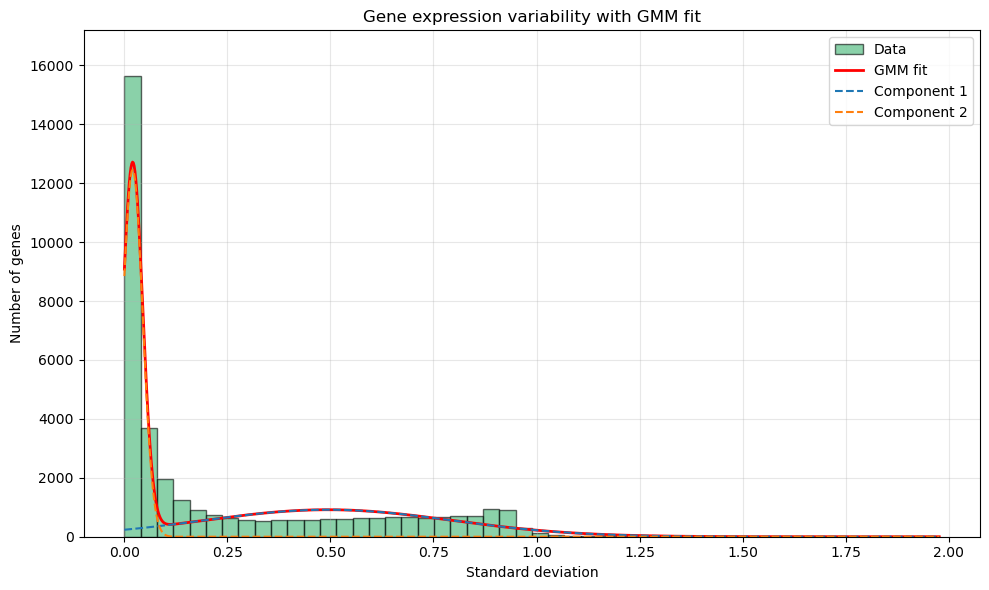

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

counts, bins, _ = ax.hist(gene_std, bins=50, alpha=0.6, color="mediumseagreen",
                          edgecolor="black", label="Data")
x = np.linspace(gene_std.min(), gene_std.max(), 1000)
scale = len(gene_std) * (bins[1] - bins[0])
ax.plot(x, np.exp(gmm.score_samples(x.reshape(-1, 1))) * scale, "r-", lw=2, label="GMM fit")
for i in range(2):
    ax.plot(x, gmm.weights_[i] * norm.pdf(x, means[i], stds[i]) * scale, "--", lw=1.5,
            label=f"Component {i + 1}")
ax.set_ylim(0, counts.max() * 1.1)
ax.set(xlabel="Standard deviation", ylabel="Number of genes",
       title="Gene expression variability with GMM fit")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Selecting only protein-coding genes

Genes are matched against the HGNC protein-coding list. Some genes in the matrix use outdated
symbols (e.g. `C12orf49`, `EPRS`), so unmatched symbols are run through the
[HGNC Multi-Symbol Checker](https://www.genenames.org/tools/multi-symbol-checker/). Those whose
current approved symbol is protein-coding are renamed in the matrix and kept.

In [13]:
hgnc = pd.read_csv(data_dir / "protein-coding_genes_HGNC.txt", sep="\t")
protein_coding_symbols = set(hgnc["symbol"])

in_hgnc = high_var.columns.isin(protein_coding_symbols)
not_in_hgnc = high_var.columns[~in_hgnc].unique().tolist()
print(f"Directly matched protein-coding: {in_hgnc.sum()}")
print(f"Not matched: {len(not_in_hgnc)}")

Directly matched protein-coding: 12717
Not matched: 4218


C:\Users\corin\AppData\Local\Temp\ipykernel_35308\90175022.py:1: DtypeWarning: Columns (35,38,45,48) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc = pd.read_csv(data_dir / "protein-coding_genes_HGNC.txt", sep="\t")


### Symbols to check with HGNC

This writes the unmatched symbols to `output/symbols_for_hgnc_check.txt`. Paste its contents
into the HGNC Multi-Symbol Checker, download the results as CSV and save them as
`data/hgnc-symbol-check.csv`. This only needs repeating if the input data or gene selection changes.

In [15]:
unmatched_file = output_dir / "symbols_for_hgnc_check.txt"
unmatched_file.write_text("\n".join(not_in_hgnc))
print(f"Wrote {len(not_in_hgnc)} symbols to {unmatched_file}")

Wrote 4218 symbols to output\symbols_for_hgnc_check.txt


### Recover protein-coding genes with alternative symbols

In [25]:
symbol_check = pd.read_csv(data_dir / "hgnc-symbol-check.csv", skiprows=1)

# When the checker returns several matches, prefer a renamed gene ("Previous symbol")
# over an alternative name ("Alias symbol"), then keep the first
priority = {"Approved symbol": 0, "Previous symbol": 1, "Alias symbol": 2}
symbol_check["priority"] = symbol_check["Match type"].map(priority).fillna(3)
symbol_check = (symbol_check.sort_values("priority", kind="stable")
                .drop_duplicates(subset="Input", keep="first"))

missing = set(not_in_hgnc) - set(symbol_check["Input"])
if missing:
    print(f"Note: {len(missing)} symbols were not run through the checker "
          "and are excluded, matching the original analysis.")

approved = symbol_check.dropna(subset=["Approved symbol"])
print(f"Unmatched by checker: {symbol_check['Approved symbol'].isna().sum()} "
      "(mostly clone-based lncRNA IDs, e.g. AC/AL accessions)")

renamed = approved[approved["Approved symbol"].isin(protein_coding_symbols)]
old_to_new = dict(zip(renamed["Input"], renamed["Approved symbol"]))

# Skip renames where the approved symbol is already a column in the matrix,
# as the two columns would be different genes under the same name
clashes = {old: new for old, new in old_to_new.items() if new in set(high_var.columns)}
if clashes:
    print(f"Skipped {len(clashes)} renames that clash with existing genes: {clashes}")
    old_to_new = {old: new for old, new in old_to_new.items() if old not in clashes}

print(f"Outdated symbols recovered as protein-coding: {len(old_to_new)}")

Note: 1239 symbols were not run through the checker and are excluded, matching the original analysis.
Unmatched by checker: 2415 (mostly clone-based lncRNA IDs, e.g. AC/AL accessions)
Skipped 2 renames that clash with existing genes: {'LINC02804': 'GPR89B', 'TNRC6C-AS1': 'TMC6'}
Outdated symbols recovered as protein-coding: 361


## Save processed dataset

In [28]:
keep = in_hgnc | high_var.columns.isin(list(old_to_new))
data = high_var.loc[:, keep].rename(columns=old_to_new)

assert not set(old_to_new.values()) & set(high_var.columns), \
    "A renamed gene clashes with a gene already in the matrix"

data[metadata_cols] = cells[metadata_cols]
print(f"Final shape: {data.shape} "
      f"({data.shape[1] - len(metadata_cols)} genes + {len(metadata_cols)} metadata columns)")
data.head()

Final shape: (7529, 13080) (13077 genes + 3 metadata columns)


,NOC2L,KLHL17,PLEKHN1,HES4,ISG15,AGRN,RNF223,C1orf159,TTLL10,TNFRSF18,...,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB,variant_class_highest_impact,gRNA,resistance_vs_control
MAP2K1_89a917-MYC_32563f-iBAR_1004-iBAR_3132,1.828301,0.0,0.000000,1.828301,1.186242,2.271060,0.000000,1.186242,0.0,0.0,...,7.865163,5.929622,5.147347,6.073195,5.386085,5.295274,7.116490,drug addiction,MAP2K1_89a917-MYC_32563f,resistance
KRAS_33f23d-AKT1_0d3896-iBAR_2012-iBAR_2016,0.000000,0.0,0.000000,0.000000,2.729886,1.771710,0.000000,0.851888,0.0,0.0,...,6.319698,5.248825,3.413911,5.087435,3.794706,2.729886,6.290327,canonical drug resistance,KRAS_33f23d-AKT1_0d3896,resistance
non_targeting_6e7013-MAP2K1_01c79e-iBAR_2875-iBAR_306,0.656677,0.0,0.365383,0.365383,3.226276,1.956888,0.365383,0.000000,0.0,0.0,...,7.406085,5.176454,4.925944,5.540379,4.870164,3.945906,7.001202,drug addiction,non_targeting_6e7013-MAP2K1_01c79e,resistance
MAP2K1_a887e8-MAP2K2_fdb5ed-iBAR_1530-iBAR_1466,1.363824,0.0,0.000000,1.363824,3.384324,0.000000,0.000000,0.000000,0.0,0.0,...,7.156132,5.389404,5.021182,5.154641,4.423419,3.148661,7.022817,drug addiction,MAP2K1_a887e8-MAP2K2_fdb5ed,resistance
KRAS_2935b9-MAP2K1_8723a6-iBAR_1879-iBAR_1910,1.463451,0.0,0.000000,0.000000,2.649160,2.431404,0.000000,0.000000,0.0,0.0,...,6.622796,4.819869,4.989106,4.774265,4.948621,3.155349,6.543462,drug addiction,KRAS_2935b9-MAP2K1_8723a6,resistance


In [29]:
data.to_csv(output_dir / "data_checkpoint.csv")